# Valutazione Classificatori su Validation Set — MaxViT-512, Fine-tuning Parziale vs Completo

Confronto delle due configurazioni di fine-tuning MaxViT-Tiny-512 addestrate su dati reali + sintetici:

| Versione | Stage MaxViT Sbloccati |
|---|---|
| **Parziale** | Solo stage 3/4 (ultimo) |
| **Completo** | Tutti e 4 |

Equivalente MaxViT-512 di [`07_Val_Classificatori_RS_AllVSPart.ipynb`](07_Val_Classificatori_RS_AllVSPart.ipynb).

**Nota metodologica:** il validation set è già stato usato durante il training (early stopping su `val_auc`
e calibrazione della soglia di Youden): l'AUC resta il criterio primario di selezione (indipendente dalla soglia),
mentre accuracy/precision/recall/F1/confusion matrix hanno qui valore descrittivo. Il test set (notebook `17`)
resta riservato alla valutazione finale.

In [1]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os
import sys

# Controlla se il notebook sta girando su Google Colab
# [notebooks bootstrap] Il blocco Colab/local originale e' stato
# neutralizzato: BASE_PATH e BASE sono gia' definiti dal bootstrap
# unificato in cima al notebook.
print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import librerie

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    classification_report, precision_score, recall_score, f1_score,
)

sys.path.insert(0, os.getcwd())
from maxvit_utils import build_maxvit_model, resolve_normalization, make_dataloader, predict_probs

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


#### Configurazione

In [3]:
PARTIAL_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'classifiers/maxvit512/02b_real_synth_partial')
FULL_EXP_DIR    = os.path.join(BASE_PATH, 'experiments', 'classifiers/maxvit512/02c_real_synth_full')

VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'val.csv')
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')

IMG_SIZE = 512
BATCH_SIZE = 8
IMAGENET_MEAN = (0.5, 0.5, 0.5)
IMAGENET_STD = (0.5, 0.5, 0.5)

OUTPUT_DIR      = os.path.join(BASE_PATH, 'results', 'classifiers/maxvit512/02v_validation_partial_vs_full')
FIGURES_DIR     = os.path.join(OUTPUT_DIR, 'figures')
TABLES_DIR      = os.path.join(OUTPUT_DIR, 'tables')
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, 'predictions')
for d in (OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, PREDICTIONS_DIR):
    os.makedirs(d, exist_ok=True)
print(f"Output salvato in: {OUTPUT_DIR}")

Output salvato in: ../results/15_val_classificatori_maxvit512_allVSpart


#### Verifica e Download Dataset

In [4]:
import zipfile, gdown

def processed_data_ready():
    if not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(VAL_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

if not processed_data_ready():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
else:
    print("Dataset già presente")

Dataset già presente


#### Creazione Dataset di Validation

In [5]:
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)
def fix_path(p):
    if os.path.isabs(p) or p.startswith('../') or p.startswith('./'):
        return p
    return os.path.join(BASE_PATH, p)

df_val['processed_path'] = df_val['processed_path'].apply(fix_path)

n_positivi = (df_val['cancer'] == 1).sum()
n_negativi = (df_val['cancer'] == 0).sum()
print(f"Validation set: {len(df_val)} immagini (cancer=1: {n_positivi}, cancer=0: {n_negativi})")

val_loader = make_dataloader(df_val, 'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE,
                              batch_size=BATCH_SIZE, shuffle=False)

Validation set: 437 immagini (cancer=1: 73, cancer=0: 364)


#### Caricamento Modelli

In [6]:
model_partial = build_maxvit_model(num_classes=1, pretrained=False)
_ckpt_path = os.path.join(PARTIAL_EXP_DIR, 'real_synth_maxvit512_final_best.pt')
assert os.path.isfile(_ckpt_path), (
    f"Modello 'Real+Synth_Part' non trovato in {_ckpt_path}. "
    f"Esegui prima il notebook di training corrispondente."
)
model_partial.load_state_dict(torch.load(_ckpt_path, map_location=DEVICE))
model_partial.to(DEVICE)
print(f"[Real+Synth_Part] Modello caricato da: {_ckpt_path}")

[Real+Synth_Part] Modello caricato da: ../experiments/exp_maxvit512_real_synth_partial/real_synth_maxvit512_final_best.pt


In [7]:
model_full = build_maxvit_model(num_classes=1, pretrained=False)
_ckpt_path = os.path.join(FULL_EXP_DIR, 'real_synth_maxvit512_all_layers_final_best.pt')
assert os.path.isfile(_ckpt_path), (
    f"Modello 'Real+Synth_All_Layers' non trovato in {_ckpt_path}. "
    f"Esegui prima il notebook di training corrispondente."
)
model_full.load_state_dict(torch.load(_ckpt_path, map_location=DEVICE))
model_full.to(DEVICE)
print(f"[Real+Synth_All_Layers] Modello caricato da: {_ckpt_path}")

[Real+Synth_All_Layers] Modello caricato da: ../experiments/exp_maxvit512_real_synth_full/real_synth_maxvit512_all_layers_final_best.pt


#### Caricamento Soglie Ottimali dal Validation Set

In [8]:
with open(os.path.join(PARTIAL_EXP_DIR, 'val_metrics.json')) as f:
    metriche_partial = json.load(f)
with open(os.path.join(FULL_EXP_DIR, 'val_metrics.json')) as f:
    metriche_full = json.load(f)

soglia_partial = metriche_partial['optimal_threshold_youden']
soglia_full = metriche_full['optimal_threshold_youden']
print(f"Soglia ottimale Real+Synth_Part:       {soglia_partial:.3f}")
print(f"Soglia ottimale Real+Synth_All_Layers: {soglia_full:.3f}")

Soglia ottimale Real+Synth_Part:       0.498
Soglia ottimale Real+Synth_All_Layers: 0.275


#### Predizioni sul Validation Set

In [9]:
print("Predizioni Real+Synth_Part...")
y_true, probs_partial = predict_probs(model_partial, val_loader, DEVICE)
print("Predizioni Real+Synth_All_Layers...")
_, probs_full = predict_probs(model_full, val_loader, DEVICE)
print("Predizioni completate")

df_predizioni = df_val[['processed_path', 'cancer']].copy().rename(columns={'cancer': 'label_true'})
df_predizioni['prob_real_synth_part'] = probs_partial
df_predizioni['prob_real_synth_all_layers'] = probs_full
df_predizioni['pred_real_synth_part'] = (probs_partial >= soglia_partial).astype(int)
df_predizioni['pred_real_synth_all_layers'] = (probs_full >= soglia_full).astype(int)

preds_path = os.path.join(PREDICTIONS_DIR, 'val_predictions.csv')
df_predizioni.to_csv(preds_path, index=False)
print(f"Predizioni salvate in: {preds_path}")

Predizioni Real+Synth_Part...
Predizioni Real+Synth_All_Layers...
Predizioni completate
Predizioni salvate in: ../results/15_val_classificatori_maxvit512_allVSpart/predictions/val_predictions.csv


#### Valutazione — Metriche per Configurazione

In [10]:
COLORS = {'Real+Synth_Part': 'tab:green', 'Real+Synth_All_Layers': 'tab:blue'}
CLASSIFICATORI = {
    'Real+Synth_Part':       (probs_partial, soglia_partial),
    'Real+Synth_All_Layers': (probs_full,    soglia_full),
}

all_metrics = {}
for nome_conf, (probs, threshold) in CLASSIFICATORI.items():
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)
    y_pred = (probs >= threshold).astype(int)

    all_metrics[nome_conf] = {
        'auc': round(float(auc), 4),
        'threshold': round(float(threshold), 4),
        'accuracy': round(float((y_pred == y_true).mean()), 4),
        'precision': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'recall': round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'f1': round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred,
    }
    print(f"\n[{nome_conf}] AUC={auc:.4f}  F1={all_metrics[nome_conf]['f1']:.4f}")
    print(classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro']))

metrics_to_save = {k: {m: v for m, v in vals.items() if m not in ('fpr', 'tpr', 'y_pred')}
                    for k, vals in all_metrics.items()}
with open(os.path.join(TABLES_DIR, 'val_comparison_metrics.json'), 'w') as f:
    json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)


[Real+Synth_Part] AUC=0.6422  F1=0.3519
              precision    recall  f1-score   support

   No cancro       0.88      0.71      0.79       364
      Cancro       0.27      0.52      0.35        73

    accuracy                           0.68       437
   macro avg       0.57      0.62      0.57       437
weighted avg       0.78      0.68      0.71       437


[Real+Synth_All_Layers] AUC=0.6491  F1=0.3381
              precision    recall  f1-score   support

   No cancro       0.91      0.40      0.56       364
      Cancro       0.21      0.81      0.34        73

    accuracy                           0.47       437
   macro avg       0.56      0.61      0.45       437
weighted avg       0.80      0.47      0.52       437



#### Distribuzione Probabilità Predette per Classe Reale

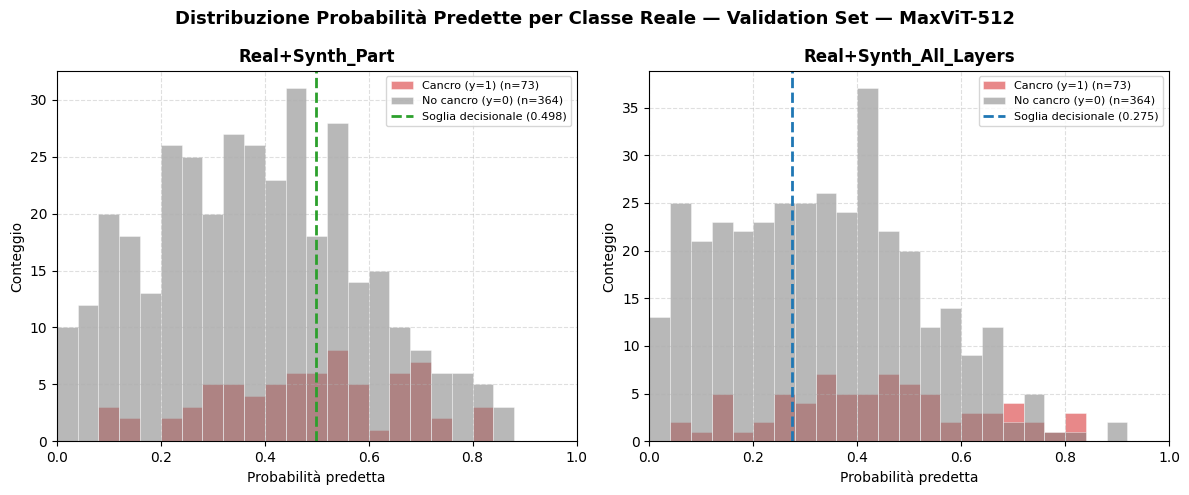

Salvato in: ../results/15_val_classificatori_maxvit512_allVSpart/figures/val_probability_distributions.png


In [11]:
COLORI_CLASSE    = {1: 'tab:red', 0: 'tab:gray'}
ETICHETTE_CLASSE = {1: 'Cancro (y=1)', 0: 'No cancro (y=0)'}

fig, axes = plt.subplots(1, len(CLASSIFICATORI), figsize=(6 * len(CLASSIFICATORI), 5), squeeze=False)
axes = axes[0]

for ax, (nome_conf, (probs, soglia)) in zip(axes, CLASSIFICATORI.items()):
    for classe in [1, 0]:
        maschera = (y_true == classe)
        prob_classe = probs[maschera]
        ax.hist(
            prob_classe, bins=25, range=(0, 1), alpha=0.55,
            color=COLORI_CLASSE[classe],
            label=f"{ETICHETTE_CLASSE[classe]} (n={int(maschera.sum())})",
            edgecolor='white', linewidth=0.5,
        )
    ax.axvline(x=soglia, color=COLORS[nome_conf], linestyle='--', linewidth=2,
               label=f'Soglia decisionale ({soglia:.3f})')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probabilità predetta')
    ax.set_ylabel('Conteggio')
    ax.set_title(nome_conf, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Distribuzione Probabilità Predette per Classe Reale — Validation Set — MaxViT-512', fontsize=13, fontweight='bold')
plt.tight_layout()
dist_path = os.path.join(FIGURES_DIR, 'val_probability_distributions.png')
fig.savefig(dist_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {dist_path}")

#### ROC Curves a Confronto

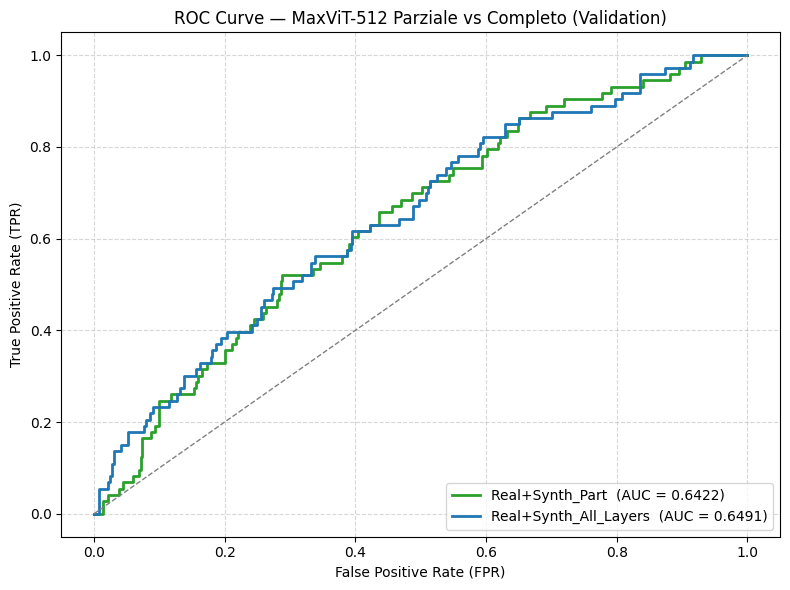

Salvato in: ../results/15_val_classificatori_maxvit512_allVSpart/figures/val_roc_curves.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
for nome_conf, m in all_metrics.items():
    ax.plot(m['fpr'], m['tpr'], color=COLORS[nome_conf], lw=2,
            label=f"{nome_conf}  (AUC = {m['auc']:.4f})")

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curve — MaxViT-512 Parziale vs Completo (Validation)')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'val_roc_curves.png')
fig.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {roc_path}")

#### Matrici di Confusione

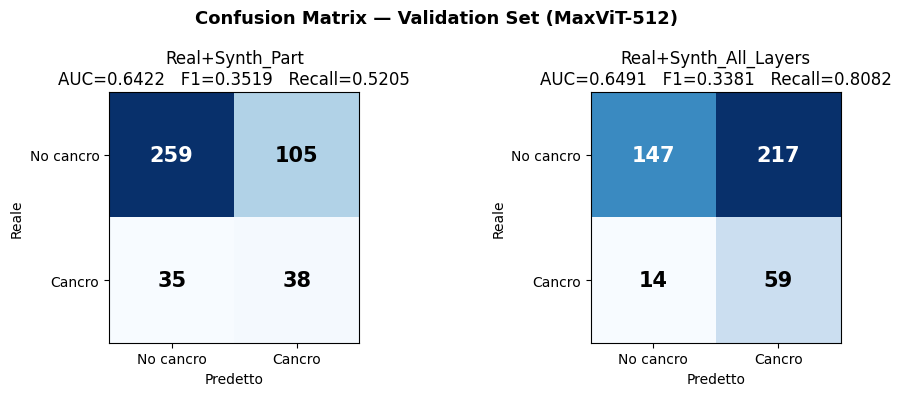

Salvato in: ../results/15_val_classificatori_maxvit512_allVSpart/figures/val_confusion_matrices.png


In [13]:
fig, axes = plt.subplots(1, len(all_metrics), figsize=(5 * len(all_metrics), 4), squeeze=False)
axes = axes[0]
for ax, (nome_conf, m) in zip(axes, all_metrics.items()):
    cm = confusion_matrix(y_true, m['y_pred'])
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No cancro', 'Cancro'])
    ax.set_yticklabels(['No cancro', 'Cancro'])
    ax.set_xlabel('Predetto'); ax.set_ylabel('Reale')
    ax.set_title(f'{nome_conf}\nAUC={m["auc"]:.4f}   F1={m["f1"]:.4f}   Recall={m["recall"]:.4f}')
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=15, fontweight='bold', color=color)

plt.suptitle('Confusion Matrix — Validation Set (MaxViT-512)', fontsize=13, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(FIGURES_DIR, 'val_confusion_matrices.png')
fig.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {cm_path}")

#### Confronto Metriche

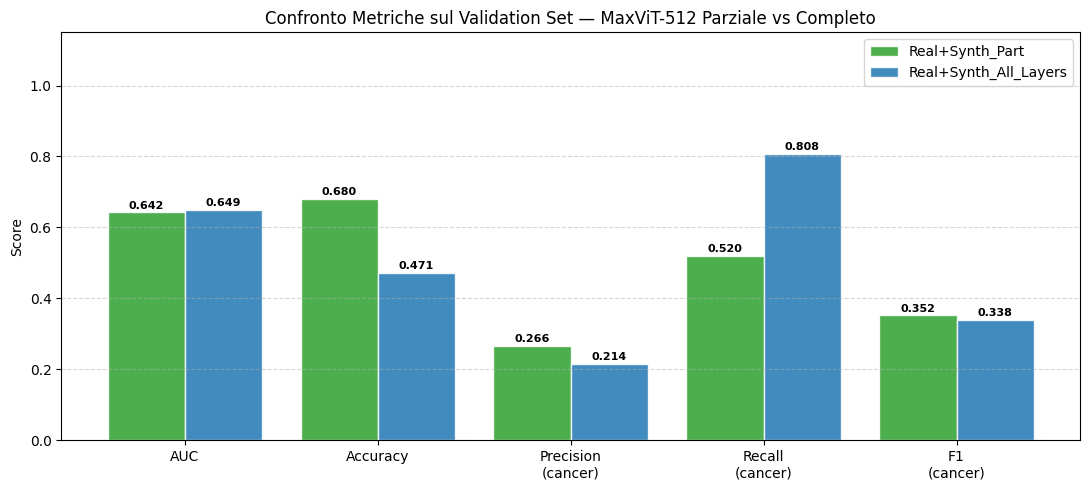

Salvato in: ../results/15_val_classificatori_maxvit512_allVSpart/figures/val_metrics_comparison.png


In [14]:
metric_keys   = ['auc', 'accuracy', 'precision', 'recall', 'f1']
metric_labels = ['AUC', 'Accuracy', 'Precision\n(cancer)', 'Recall\n(cancer)', 'F1\n(cancer)']

nomi = list(all_metrics.keys())
x = np.arange(len(metric_keys))
width = 0.8 / max(len(nomi), 1)

fig, ax = plt.subplots(figsize=(11, 5))
for i, nome_conf in enumerate(nomi):
    vals = [all_metrics[nome_conf][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=nome_conf,
                  color=COLORS.get(nome_conf, 'tab:blue'), alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width * (len(nomi) - 1) / 2)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Confronto Metriche sul Validation Set — MaxViT-512 Parziale vs Completo')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
bar_path = os.path.join(FIGURES_DIR, 'val_metrics_comparison.png')
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {bar_path}")